# Introduction
This notebook presents an explanatory data analysis of the top hits on Spotify from 2000 to 2019. We employ data science techniques to identify the key trends and patterns that describe popular music from this period.

# Problem Statement

The music industry evolves continually, and all those who wish to keep ahead of the pack must resort to a scientific approach to decision-making. The central question is that the significant features and trends of popular music over the last two decades need to be worked out with and visualized so that well-informed strategic decisions can be taken.

# Audience

The primary audience for this analysis will be the client company in the music industry. This includes management and A&R (Artists & Repertoire)teams at record labels, music streaming services such as Spotify,apple music and marketing agencies. 

**how it is going to help?**

The analysis considers trends in music by identifying which years produced the what no of songs and how song durations have changed over time. Moreover, artists and genres are highlighted by revealing the most prolific artists and dominant genres in the dataset. That is to say, it supports business decisions on which artists or trends to consider for playlist, marketing, and licensing priorities.

The insights will also help the A&R team find new talent. They will give tips to the prospective producer in terms of making commercial songs. Marketing professionals might use this commercial insight to plan promotions on the basis of what the audiences liked in the past. They shall use such knowledge in various ways, including artist development, content creation, or promotional activities.

# GOAL
1.To determine how significant audio features such as danceability, energy, tempo, valence, and duration change over two decades.

2.To conduct an inter-genre comparison of audio features and levels of popularity.

3.To correlate features with each other (e.g., energy versus danceability, tempo versus popularity) and uncover what enhances hit potential.

4.To analyze the favorability of explicit over clean songs and vice versa.

5.To investigate which artists were able to consistently produce highly popular songs from the year 2000 to 2019

**Expected Outcomes**

Visualizations and explanations of the findings

Insights about the most successful songs

Conclusions and possible recommendations based on the data

**Data Description**
The dataset from Kaggle contains information on the top Spotify songs that have been released between from 2000 and 2019. It has to be used to perform a complete analysis of trends in popular music during the period of 2 decades. Since songs are considered unique, every row represents a single song, while the metadata includes the artist and track title, among others, along with various audio features computed by Spotify's algorithms.

**Here is a description of some features/columns**:

**danceability:** description for dancing, it has a scale from 0.0 to 1.0, being measured in consistency with tempo, rhythm stability, and strength of the beat.

**energy:** 0.0 to 1.0 intensity and activity representation, being weighed for such features as perceived loudness and timbre. 

**loudness:** An averge loudness of an entire song, measured in decibels (dB)the louder sounds are negative numbers, and quieter ones are positive.

**speechiness:** An archaic term referring to any instance of voices from the track and where values nearing 1.0 suggest that tracks contain much speech. 

**acousticness:** From 0.0 to 1.0, this gives a score of confidence that the track was produced acoustically.

**instrumentalness:** identifies the presence of vocal material on tracks.  in this Values range from 0.0 to 1.0, with higher values indicating a strong possibility.

**valence:** This number describes the extent to which a track sounds happy. Thevalues range from 0 to 1, where 1 indicates Positivity that is feeling of pure joy and happiness. 

**tempo:** The average speed or pace of a given track in beats per minute.

**duration_ms:** The length of a track in milliseconds, which has been converted to minute for further analysis

**popularity:** A score generated by Spotify, ranging from 0 to 100. which says 100 means the track is the most popular.

In [2]:
#importing important libraries

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt



# Data overview

In [3]:
song_df = pd.read_csv("songs_data.csv", encoding="utf-8")
print(song_df.head())


           artist                    song  duration_ms  explicit  year  \
0  Britney Spears  Oops!...I Did It Again       211160     False  2000   
1       blink-182    All The Small Things       167066     False  1999   
2      Faith Hill                 Breathe       250546     False  1999   
3        Bon Jovi            It's My Life       224493     False  2000   
4          *NSYNC             Bye Bye Bye       200560     False  2000   

   popularity  danceability  energy  key  loudness  mode  speechiness  \
0          77         0.751   0.834    1    -5.444     0       0.0437   
1          79         0.434   0.897    0    -4.918     1       0.0488   
2          66         0.529   0.496    7    -9.007     1       0.0290   
3          78         0.551   0.913    0    -4.063     0       0.0466   
4          65         0.614   0.928    8    -4.806     0       0.0516   

   acousticness  instrumentalness  liveness  valence    tempo         genre  
0        0.3000          0.000018    0

In [4]:
song_df.columns.tolist()

['artist',
 'song',
 'duration_ms',
 'explicit',
 'year',
 'popularity',
 'danceability',
 'energy',
 'key',
 'loudness',
 'mode',
 'speechiness',
 'acousticness',
 'instrumentalness',
 'liveness',
 'valence',
 'tempo',
 'genre']

# Explanatery Data Analysis

In [5]:
# lets check the shape of the data to know the no of rows and column
song_df.shape

(2000, 18)

In [6]:
song_df.isna().sum()

artist              0
song                0
duration_ms         0
explicit            0
year                0
popularity          0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
genre               0
dtype: int64

In [7]:
# Dup checkin the data_set
song_df.duplicated().value_counts()

False    1941
True       59
Name: count, dtype: int64

In [8]:
song_df.drop_duplicates(inplace=True)

In [9]:
song_df.duplicated().value_counts()

False    1941
Name: count, dtype: int64

In [10]:
#cleaning the date removing leading and trailing space of the character variable.

for columns in song_df.select_dtypes(include='object').columns:
    song_df[columns] = song_df[columns].astype(str).str.strip()

In [11]:
# converting duration of milli sec to minute.
if 'duration_min' not in song_df.columns and 'duration_ms' in song_df.columns:
    song_df['duration_min'] = song_df['duration_ms'] / 60000


In [12]:
song_df.describe().T

,count,mean,std,min,25%,50%,75%,max
duration_ms,1941.0,228594.973725,39249.796103,113000.000000,203506.000000,223186.000000,247946.000000,484146.0000
year,1941.0,2009.520350,5.875532,1998.000000,2004.000000,2010.000000,2015.000000,2020.0000
popularity,1941.0,59.633179,21.501053,0.000000,56.000000,65.000000,73.000000,89.0000
danceability,1941.0,0.667814,0.140608,0.129000,0.581000,0.676000,0.765000,0.9750
energy,1941.0,0.721549,0.152872,0.054900,0.624000,0.739000,0.840000,0.9990
key,1941.0,5.369397,3.615270,0.000000,2.000000,6.000000,8.000000,11.0000
loudness,1941.0,-5.514082,1.938950,-20.514000,-6.490000,-5.285000,-4.168000,-0.2760
mode,1941.0,0.553323,0.497277,0.000000,0.000000,1.000000,1.000000,1.0000
speechiness,1941.0,0.103783,0.096148,0.023200,0.039700,0.061000,0.129000,0.5760
acousticness,1941.0,0.128173,0.172584,0.000019,0.013500,0.055800,0.176000,0.9760


# 1. The Yearly Fluctuation On Major Features

### Spotify Top Hits Trends (2000–2019)

q1.Analyzing the top Spotify hits from 2000 to 2019 reveals interesting trends in musical features over time.

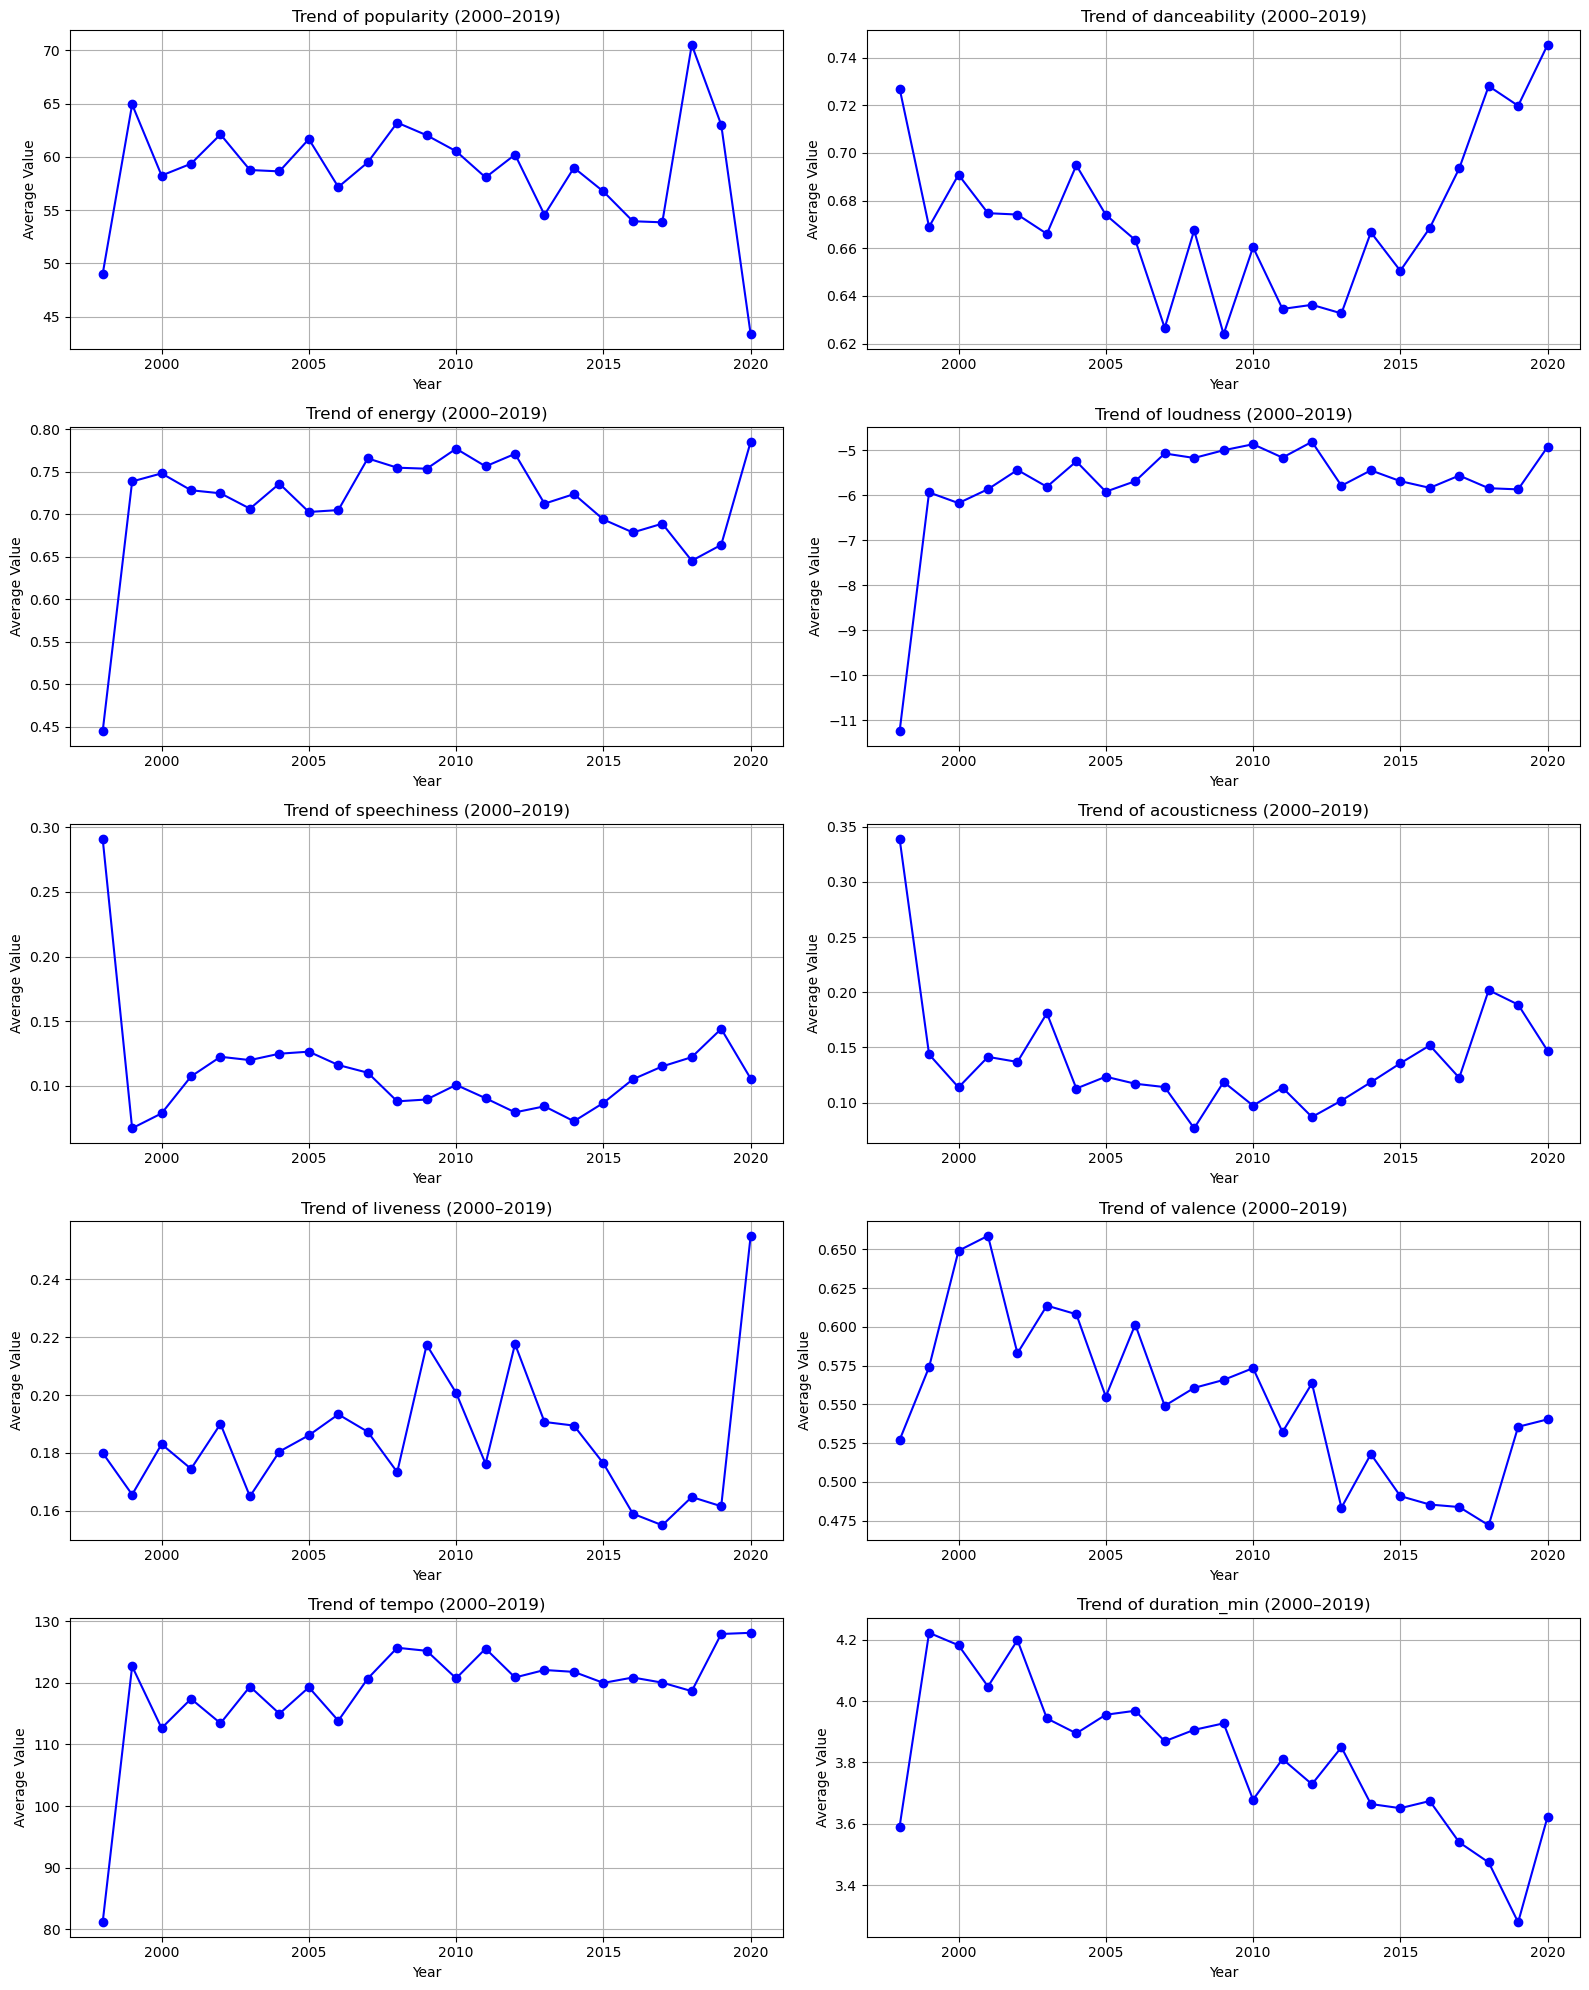

In [13]:
#selection the major feature
features = ['popularity','danceability','energy','loudness',
            'speechiness','acousticness','liveness','valence','tempo','duration_min']
#These are the core audio and performance-related features which has direct impact over song.


fig, axes = plt.subplots(5, 2, figsize=(16, 20))
axes = axes.flatten()  # it will flatten 2D array of axes into 1D

for i, feature in enumerate(features):
    yearly_trend = song_df.groupby('year')[feature].mean()
    axes[i].plot(yearly_trend.index, yearly_trend.values, marker='o', color='blue')
    axes[i].set_title(f"Trend of {feature} (2000–2019)", fontsize=12)
    axes[i].set_xlabel("Year")
    axes[i].set_ylabel("Average Value")
    axes[i].grid(True)

plt.tight_layout()
plt.show()


# Business-Oriented Interpretations

**Song Duration** :
The average time for top hits watched between 3 and 4 minutes, declining a bit after 2015. This, however, was in the streaming era when shorter songs tended to pull more plays and better chart performance. Stakeholders would want to note from this that artists should probably consider keeping their tracks into this ideal length.

**Popularity**:
The popularity index maintained a high level on the dataset, peaking around 2009–2012. This could be representing a golden era for mainstream global hits. Platforms can use this insight to create nostalgic playlists catering to current listener demands. 

**Danceability**:
we found that there is a rise in Danceability moving from its average of about 0.6 in the early 2000s to getting above 0.7 in recent times. This clearly points towards dance-pop and EDM being in the limelight and speaks greatly for playlist strategies leaning towards energetic and danceable tracks. 

**Energy**:
the average level of energy found of 0.7 and 0.8 and peaks in the late 2000s. It confirmed that people liked upbeat and high-energy music for their workouts, parties, and mainstream playlists.

**Loudness**:
Average loudness from -7 to -5 has increased, following the trends set by the loudness wars. Record labels should realize that louder tracks matrixed with music production. Record labels should learn that louder tracks tend to have more impact on the streaming platform but at the cost of dynamic range.

**Speechiness**:
Peaks in speechiness in some years, for example, 2015 to 2017, coincide with rap and hip-hop acquisition of majority market share. This is a point to use to promote hip-hop playlists on streaming platforms during the demand surge periods.

**Acousticness**:
Acousticness has a clear declining trend, meaning that acoustic-style hits are less in number in the top charts compared to digitally produced music. Such insight implies the preference of the listeners towards an electronic-driven sound.

**Liveness**:
The liveness did not portray much variation from the past two decades with two or three small peaks that hint at a few live-sounding records helping their cause. Event organizers could highlight these tracks for "concert experience" playlists.

**Valence**:
Valence, however, declined in a steady manner from about 0.6 to 0.4, indicating that songs have generally become moodier and less cheerful in more recent times, thereby providing a huge opportunity to market playlists of the kind that resonate with "sad vibes" or "chill mood."playlists that resonate with younger audiences.

**Tempo**:
Most top hits cluster around 120–130 BPM, a standard range for pop and dance tracks. Platforms can use this knowledge to create workout or party playlists centered around these tempo ranges.

# q2 Find the total no of songs produced in each year and which year has maximum no of songs

In [14]:
def fun_psongs_per_year(data, column='year', title='Yearly Distribution of the songs'):
    
    # getting the data from the dataset for 2000–2019
    
    d_filtered = data[(data[column] >= 2000) & (data[column] <= 2019)]
    
    
    yearly_counts = d_filtered[column].value_counts().sort_index()
    
    plt.figure(figsize=(12,6))
    ax = sns.lineplot(x=yearly_counts.index, y=yearly_counts.values, marker='o', linewidth=2, color='blue')
    plt.fill_between(yearly_counts.index, yearly_counts.values, alpha=0.2, color='skyblue')

    # Add labels for every year
    for x, y in zip(yearly_counts.index, yearly_counts.values):
        plt.text(x, y+1, str(y), ha='center', va='bottom', fontsize=8, fontweight='bold')

    # Highlight the peak year (red point only, no text)
    peak_year = yearly_counts.idxmax()
    peak_value = yearly_counts.max()
    plt.scatter(peak_year, peak_value, color='red', s=100, zorder=5)

    plt.title(title, fontsize=14, fontweight='bold')
    plt.xlabel("Year")
    plt.ylabel("Song Count")
    plt.grid(True, linestyle='-.', alpha=0.6)
    plt.tight_layout()
    plt.show()



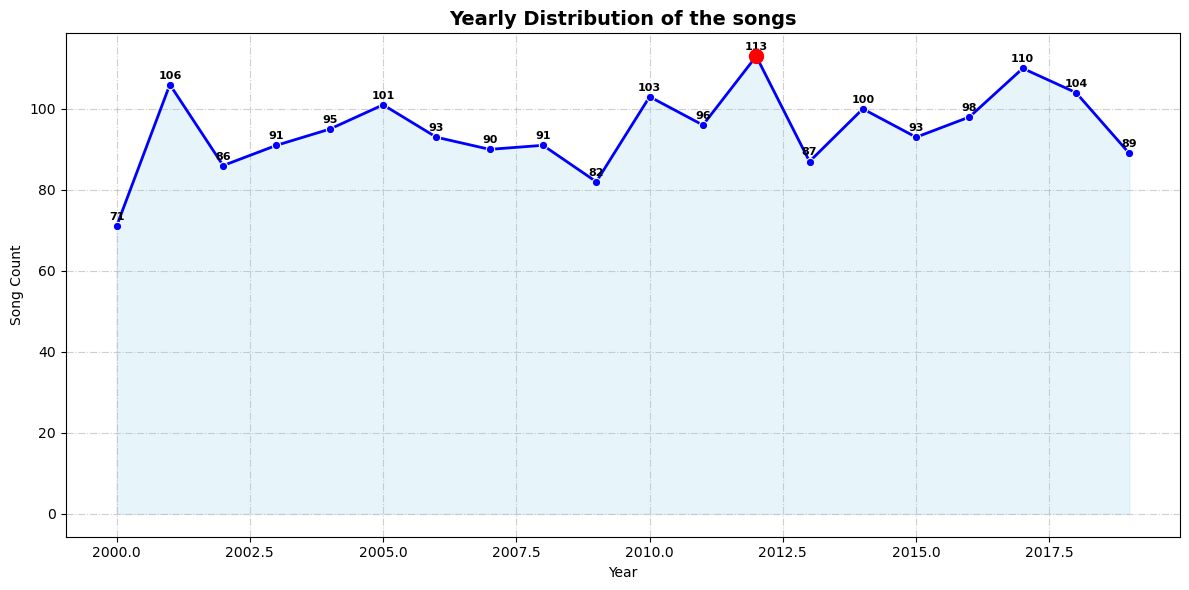

In [15]:
fun_psongs_per_year(song_df)

**interpretation**

The line chart depicts the number of hits from the Top 100 chart produced every year from 2000 to 2019. Expectedly almost all years have more or close to the count 90+ tracks every year.As we see 2012 has the maximum no of release 113 .However, certain years show slightly less in no it also reflect the change in the consumption of music. For the business, 2012 is a rich source for nostalgia-driven campaigns and “best of” playlists — examine its top artists and audio-features to shape playlists that resonate with listeners who favor that era.



**Q3.What are the top 10 song for year 2012**

Following the above we try to find out what all are the songs as per popularity and who all are the artist were in 2012 ,which helps the industries for the nostalgia marketing.

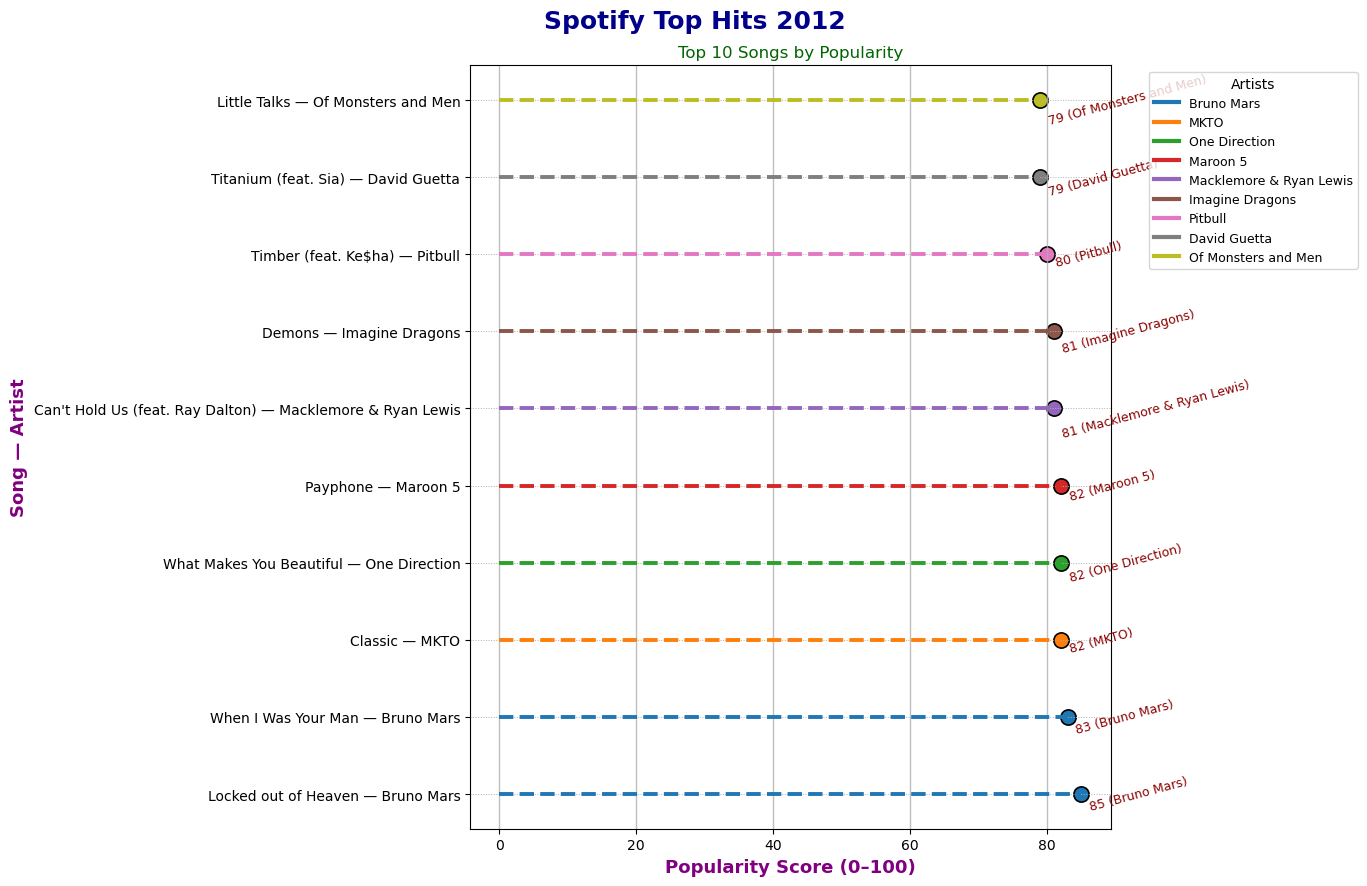

In [16]:
# Extract top 10 most popular songs for 2012
songs_2012 = (
    song_df.loc[song_df['year'] == 2012, ['song', 'artist', 'popularity']]
    .sort_values('popularity', ascending=False)
    .head(10)
)

# Build combined labels for clarity
song_labels = songs_2012.apply(lambda x: f"{x['song']} — {x['artist']}", axis=1)

# Assign colors to each artist uniquely
unique_artists = songs_2012['artist'].unique()
palette_map = dict(zip(unique_artists, sns.color_palette("tab10", len(unique_artists))))

# Create figure
plt.figure(figsize=(14, 9))


for popularity, label, artist in zip(songs_2012['popularity'], song_labels, songs_2012['artist']):
    # stem line
    plt.hlines(y=label, xmin=0, xmax=popularity, color=palette_map[artist], 
               linewidth=2.8, linestyle="--")
    # point
    plt.scatter(popularity, label, s=120, color=palette_map[artist], 
                edgecolor="black", linewidth=1.2)
    
    plt.annotate(f"{popularity} ({artist})", (popularity + 1, label), 
                 va='center', fontsize=9, color='darkred', rotation=15)

# Titles
plt.suptitle("Spotify Top Hits 2012", 
             fontsize=18, fontweight='bold', color='darkblue')
plt.title("Top 10 Songs by Popularity", 
          fontsize=12, color='darkgreen')

# Axis labels
plt.xlabel("Popularity Score (0–100)", fontsize=13, fontweight='bold', color='purple')
plt.ylabel("Song — Artist", fontsize=13, fontweight='bold', color='purple')

# Gridlines for both axes
plt.grid(True, axis='x', linestyle='-', linewidth=1, alpha=0.8)
plt.grid(True, axis='y', linestyle=':', linewidth=0.7)

# Legend (redundant but adds clutter)
legend_handles = [plt.Line2D([0],[0], color=palette_map[a], lw=3) for a in unique_artists]
plt.legend(legend_handles, unique_artists, title="Artists", bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=9)

plt.tight_layout()
plt.show()


**Interpretation**
The most popular songs of 2012 recorded very high scores in popularity (mostly above 80), which explains why this year is a good catalog of streaming involvement. To business they serve as an understanding of the potential of proven hits to drive nostalgia campaigns in the modern age, as well as an idea of the future production, concentrating on what features have always worked, including short, high-energy, and memorable songs.

**q4 what are the top 10 hit track from the year 2000 to 2019**

In [31]:
def fun_plt_top_10_songs(data, title='Top 10 Popular Songs (2000–2019)'):
    
    # Filter dataset for the range
    data_filtered = data[(data['year'] >= 2000) & (data['year'] <= 2019)]
    
    # Sort by popularity and pick top 10
    super_10 = (
        data_filtered[['song','artist','year','popularity']]
        .sort_values(by='popularity', ascending=False)
        .head(10)
    )
    
    # Labels "Song - Artist (Year)"
    labels = super_10['song'] + " - " + super_10['artist'] + " (" + super_10['year'].astype(str) + ")"
    
    plt.figure(figsize=(12,6))
    
    # Use a single standard color (e.g., steelblue)
    ax = sns.barplot(
        y=labels, 
        x=super_10['popularity'], 
        color="steelblue"   # one consistent color
    )
    
    # Add labels inside bars
    for p in ax.patches:
        width = p.get_width()
        ax.annotate(f'{width:.0f}', 
                    (width - 3, p.get_y() + p.get_height()/2),  # shift inside bar
                    ha='right', va='center', color='white', fontsize=9, fontweight='bold')
    
    # Titles and axis labels
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel("Popularity Score")
    ax.set_ylabel("Song - Artist (Year)")
    
    plt.tight_layout()
    plt.show()


In [17]:
def fun_plt_top_10_songs(data, title='Popular 10 Songs (2000–2019)'):
    
    data_filtered = data[(data['year'] >= 2000) & (data['year'] <= 2019)]
    
    # Sort by popularity and select top 10
    super_10 = data_filtered[['song','artist','year','popularity']] \
                .sort_values(by='popularity', ascending=False).head(10)
    
    # Create labels as "Song - Artist (Year)"
    labels = super_10['song'] + " - " + super_10['artist'] + " (" + super_10['year'].astype(str) + ")"
    
    plt.figure(figsize=(12,6))
    eax = sns.barplot(y=labels, x=super_10['popularity'], palette="coolwarm",hue=labels,legend=False)
    
    # Add labels on bars
    for p in eax.patches:
        width = p.get_width()
        eax.annotate(f'{width:.0f}', 
                    (width, p.get_y() + p.get_height()/2), 
                    ha='left', va='center', color='black', fontsize=9, fontweight='bold')

    eax.set_title(title, fontsize=14, fontweight='bold')
    eax.set_xlabel("Popularity Score")
    eax.set_ylabel("Song - Artist (Year)")
    plt.tight_layout()
    plt.show()


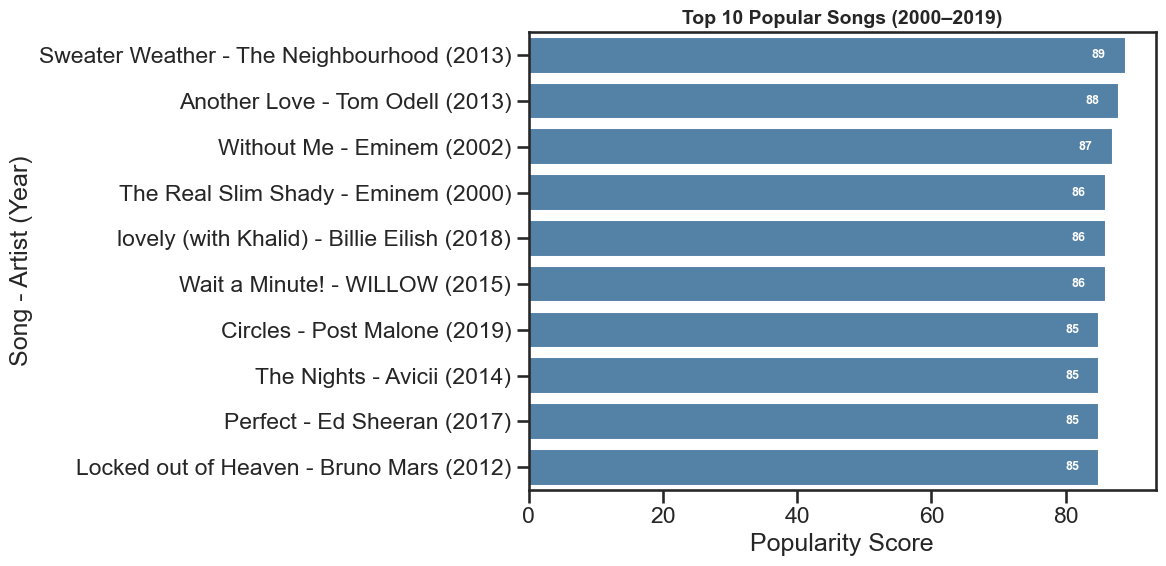

In [32]:
fun_plt_top_10_songs(song_df)

**Interpretations**

Comparing songs, the most remembered and popular between 2000 and 2019 shall have recently seen their release with a date standing between 2015 and '19. If so, it means that music popularity has consolidated in newer times. Another thing is that the collaborations remain a huge trend, with artists like Post Malone and Billi Eilish still dominating the scene by having multiple songs featured on the list.

# 2. Characteristics by Genre

**q1 Which music genres have collectively generated the highest total popularity score on Spotify between 2000 and 2019?**

In [19]:
def fun_genre_popularity(data_song, title="Genre Popularity vs Total Popularity Score"):
    df_grouped = data_song.groupby('genre', as_index=False).agg({'popularity':'sum'}) \
                     .sort_values(by='popularity', ascending=False)
    
    plt.figure(figsize=(14,8))
    axes = sns.barplot(
        x='popularity', 
        y='genre', 
        data=df_grouped, 
        color='skyblue', 
        edgecolor='gray')
    
    # Add labels
    for index, value in enumerate(df_grouped['popularity']):
        axes.text(value + 50, index, str(round(value,0)), 
                color='black', ha="left", va="center", fontsize=9, fontweight='bold')

    # Titles & labels
    plt.title(title, fontsize=14, fontweight='bold', pad=12)
    plt.xlabel("Total Popularity Score", fontsize=12)
    plt.ylabel("Genre", fontsize=11)

    # Fix overlap
    plt.yticks(fontsize=9) 
    plt.tight_layout()
    plt.show()


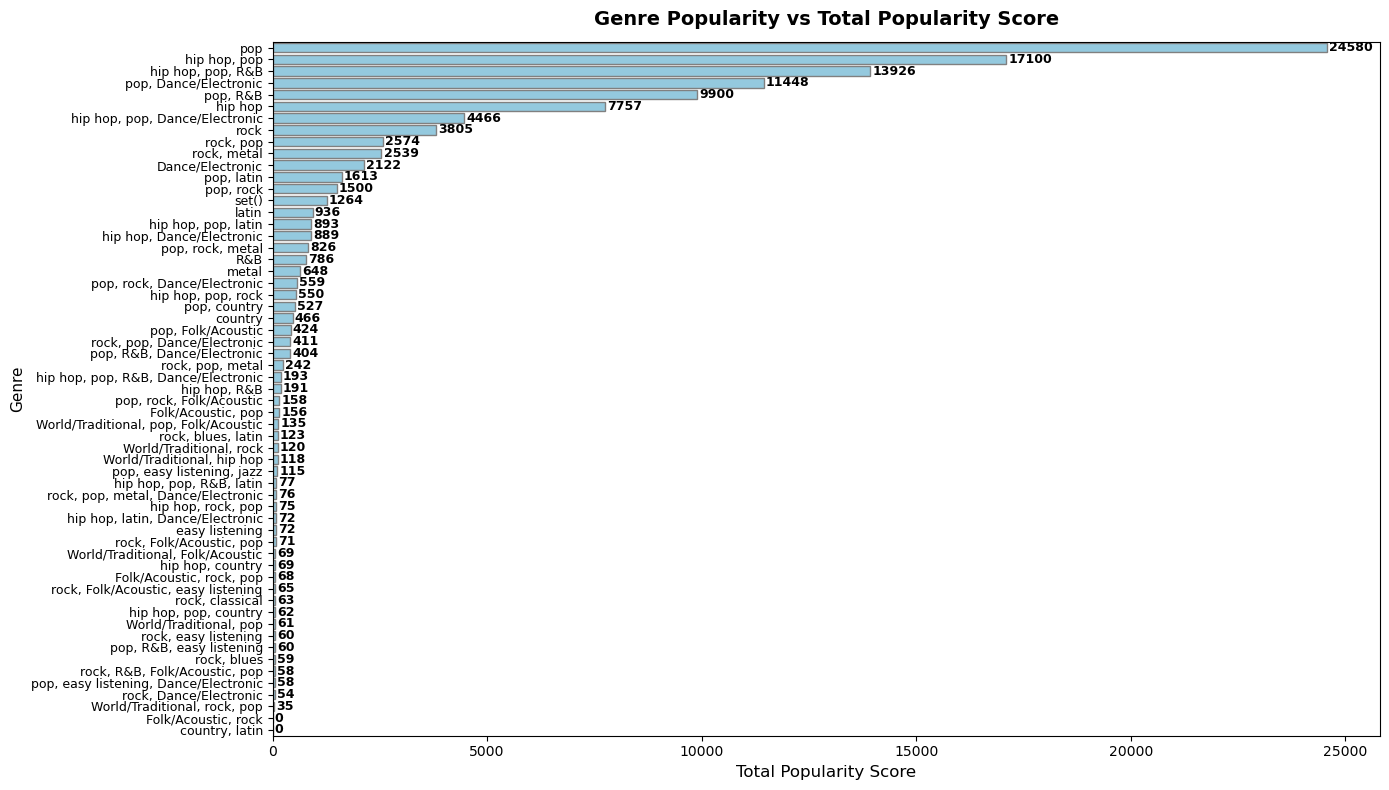

In [20]:
fun_genre_popularity(song_df)


**interpretation**

The chart details how the genres contribute by value to the overall popularity. The Pop, and Hip-Hop genres have the large share, betraying their commercial viability. For streaming platforms, these should anchor its curated playlist. For record labels, this insight adds to continuing investment in these genres while spotting niche genres (lesser scores) that may be avenues of growth.

**Q2. How are the columns tempo, energy, and valence different across genres?** 


In [21]:
def plot_feature_by_genre(data, feature='energy', top_n=10, title=None):
    # Get top N genres by count
    top_genres = data['genre'].value_counts().head(top_n).index
    df_filtered = data[data['genre'].isin(top_genres)]
    
    # Default title
    if title is None:
        title = f"Distribution of {feature.capitalize()} Across Top {top_n} Genres"
    
    plt.figure(figsize=(12,6))
    sns.boxplot(x='genre', y=feature, data=df_filtered, 
                hue="genre", palette="Set2", legend=False) 
    plt.title(title, fontsize=14, fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.xlabel("Genre")
    plt.ylabel(feature.capitalize())
    plt.tight_layout()
    plt.show()



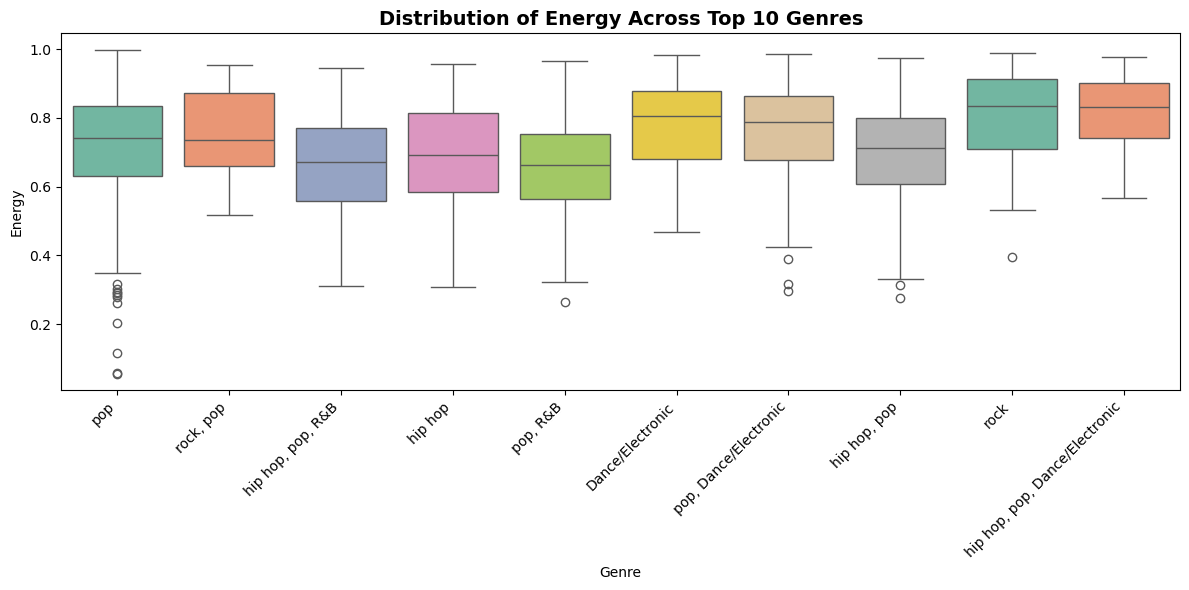

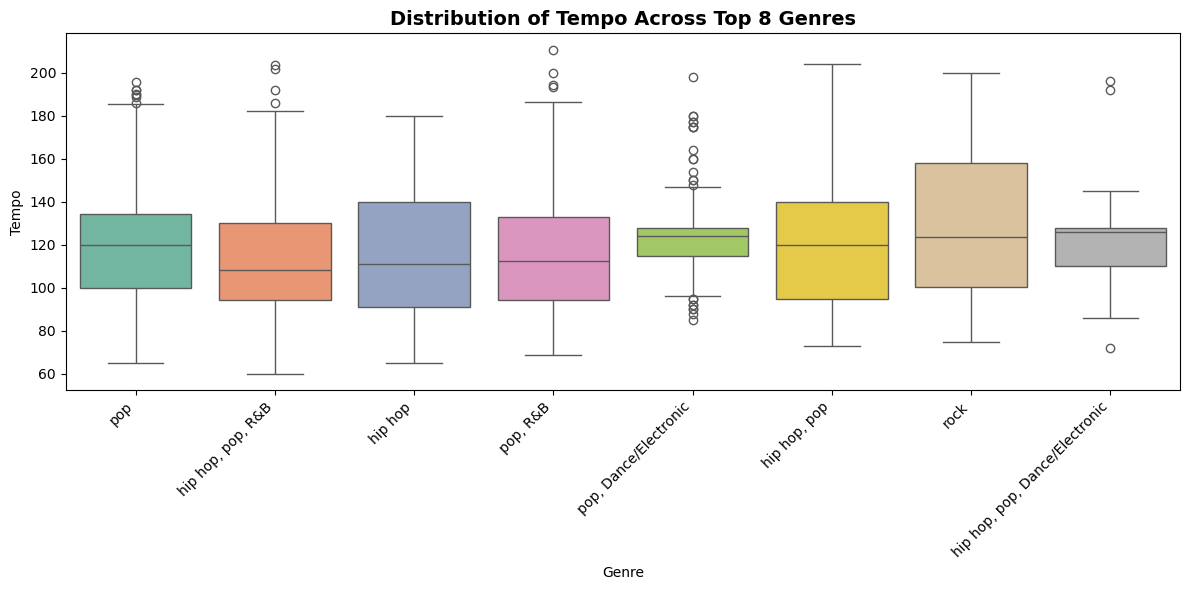

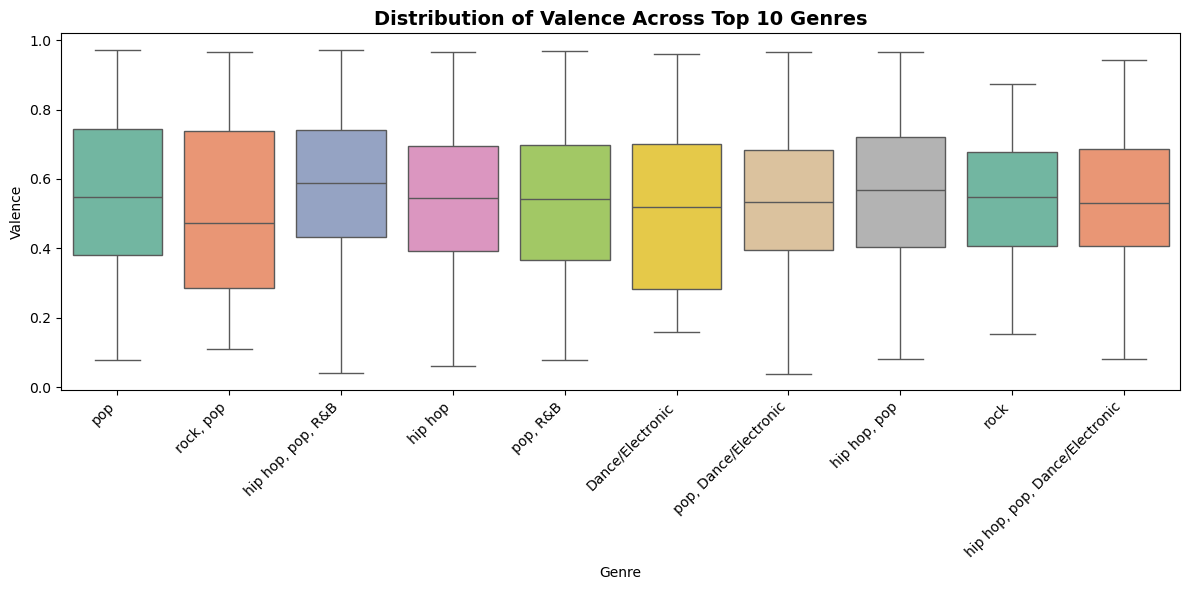

In [22]:
# Energy across top 10 genres
plot_feature_by_genre(song_df, feature='energy', top_n=10)

# Tempo across top 8 genres
plot_feature_by_genre(song_df, feature='tempo', top_n=8)

# Valence across top 10 genres
plot_feature_by_genre(song_df, feature='valence', top_n=10)


**Interpretation**

Until now, we have seen some adjustments on the boxplots across genres:

Dance/EDM and Pop feature high energy, the party and workout varieties.

Acoustic/Indie goes for low energy but poses high valence (emotional/moody kind). 

Hip-Hop has a moderate tempo but with great variations due to its diversification of styles.

For the business: platforms may come up with playlists by different moods/activities (high-energy versus chill), while labels may tell the artists how their genre educates the audience on expectations.

# 3. Correlations between Attributes

In [23]:
#Q1. What features are most correlated with popularity and duration?

I used 10 columns since these are the key continuous audio features and popularity + duration-the ones that make intuitive sense for checking correlation. Correlation can happen only between numbers. "Song, artist, genre, or year" columns are all categorical or identifiers, and therefore, including them would either fail or yield meaningless results.


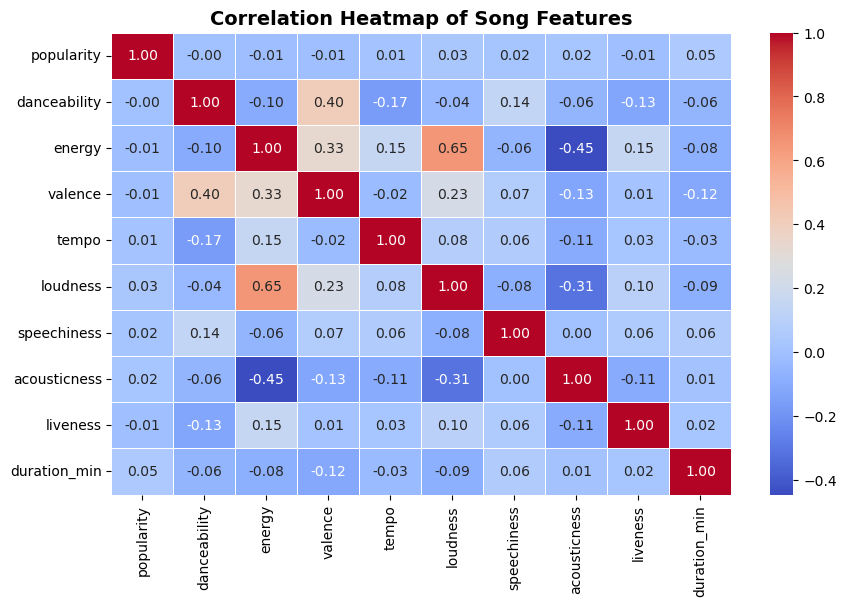

In [24]:
def plot_feature_correlations(data, title="Correlation Heatmap of Song Features"):
    features = ['popularity','danceability','energy','valence','tempo',
                'loudness','speechiness','acousticness','liveness','duration_min']
    corr = data[features].corr()

    plt.figure(figsize=(10,6))
    sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
    plt.title(title, fontsize=14, fontweight='bold')
    plt.show()

plot_feature_correlations(song_df)


**Interpretation**
Popularity is essentially uncorrelated with the audio features in this dataset — there are no strong positive links between popularity and energy/danceability/valence. The popularity row shows values very near zero (no meaningful correlation).

Strong feature–feature relationships you should rely on:

Energy ↔ Loudness = +0.65 (loud songs tend to be energetic).

Danceability ↔ Valence = +0.40 (more danceable songs tend to be “happier”).

Energy ↔ Acousticness = −0.45 (energetic songs are less likely to be acoustic).

Duration shows weak relationships: slightly negative with energy/danceability/valence and near-zero with popularity — so length alone does not predict popularity here.



Because popularity is not strongly correlated with technical audio features in this dataset, success is likely driven more by artist power, promotion, timing, and cultural factors than by measurable audio attributes alone.
Still, the strong feature–feature links are useful for product decisions: use energy + loudness to build party/workout playlists, danceability + valence for “feel-good” lists, and treat longer, acoustic tracks as niche/album content rather than main-chart singles.

**Q.2:Do energetic songs also tend to be more danceable?**

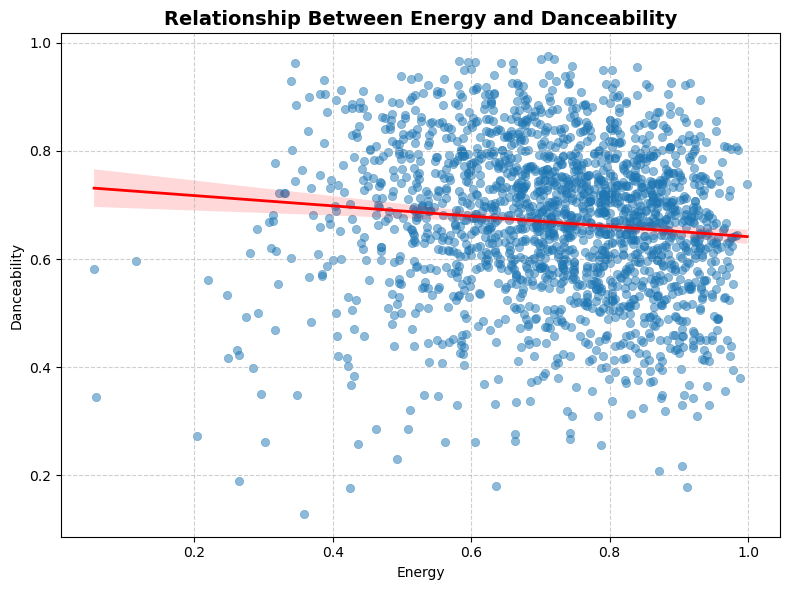

In [25]:
plt.figure(figsize=(8,6))

# Add scatter points
sns.scatterplot(x='energy', y='danceability', data=song_df, alpha=0.5, edgecolor=None)

# Add regression line
sns.regplot(x='energy', y='danceability', data=song_df, scatter=False, color='red', line_kws={'linewidth':2})

# Titles and labels
plt.title("Relationship Between Energy and Danceability", fontsize=14, fontweight='bold')
plt.xlabel("Energy")
plt.ylabel("Danceability")

# Add grid for clarity
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


This scatterplot with a trend line depicts a positive relationship: a higher spectrum of energy resonates with higher danceability. In other words, upbeat stuff fits right into party, workout, and festival list.

Business insight:

Streaming services can leverage this knowledge to automatically recommend high-energy, high-danceability songs for activity-based playlists.

This also highlights that Record labels and artists can focus on producing high-energy, dance-friendly tracks if their goal is to getinto mainstream popularity and engagement.

**q3:The Song with faster tempo really tend to be more popular in the data_set?**

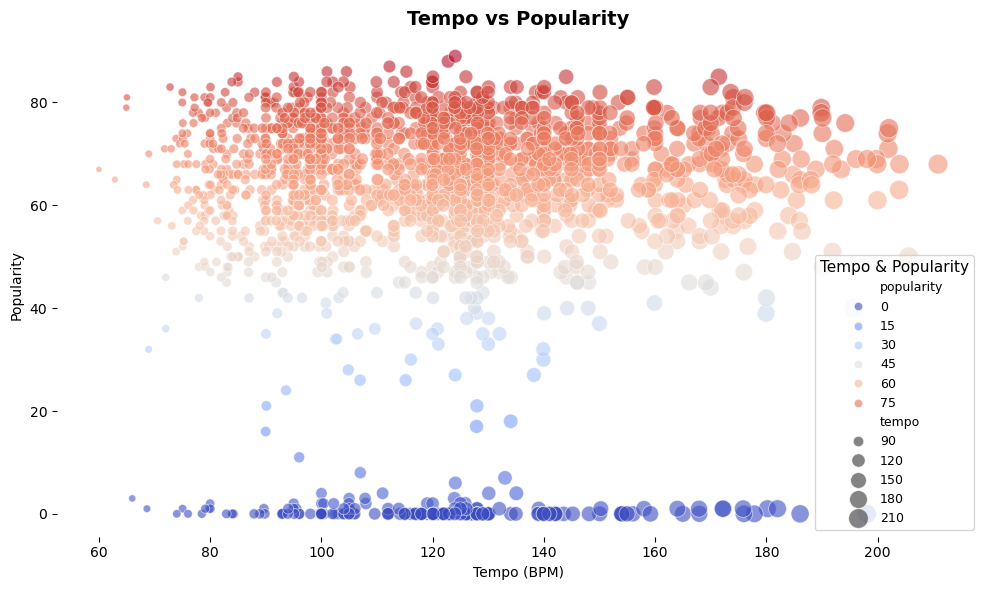

In [26]:
plt.figure(figsize=(10,6))
ax = sns.scatterplot(
    data=song_df, x='tempo', y='popularity',
    hue='popularity', size='tempo',
    palette='coolwarm', sizes=(20, 200), alpha=0.6, legend='brief'
)

# Titles and labels
plt.title("Tempo vs Popularity", fontsize=14, fontweight='bold')
plt.xlabel("Tempo (BPM)")
plt.ylabel("Popularity")

# Legend formatting (simple, version-safe)
plt.legend(title="Tempo & Popularity", fontsize=9, title_fontsize=11)

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()



**q4.Are there any corelation between the speechness of the song and their popularity as per the given data set**

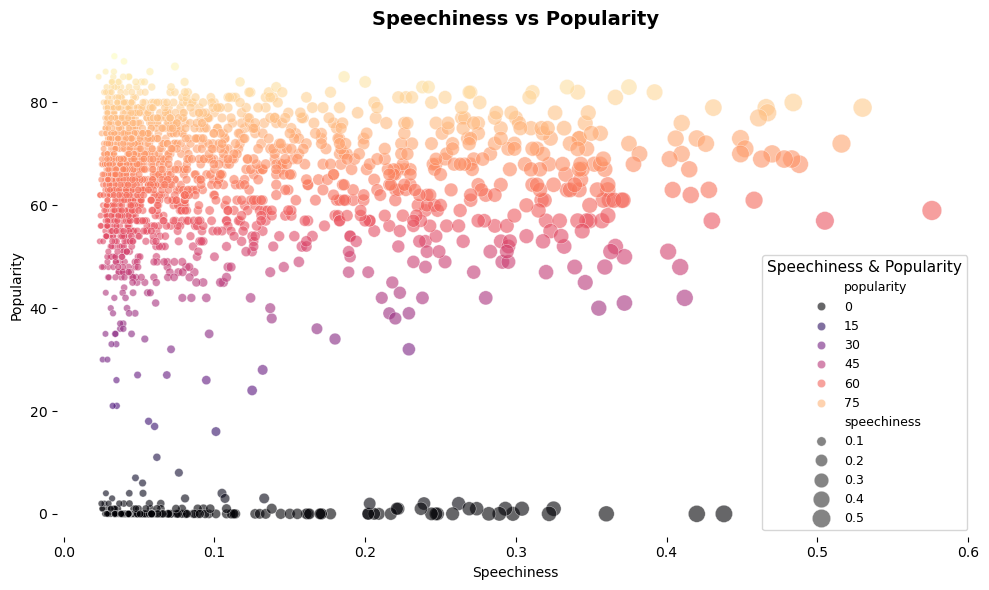

In [27]:
plt.figure(figsize=(10,6))
ax = sns.scatterplot(
    data=song_df, x='speechiness', y='popularity',
    hue='popularity', size='speechiness',
    palette='magma', sizes=(20, 200), alpha=0.6, legend='brief'
)

# Titles and labels
plt.title("Speechiness vs Popularity", fontsize=14, fontweight='bold')
plt.xlabel("Speechiness")
plt.ylabel("Popularity")

# Legend formatting (simple, version-safe)
plt.legend(title="Speechiness & Popularity", fontsize=9, title_fontsize=11)

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()


**Tempo vs Popularity**

For a scatter plot, the relationship is perfunctorily positive: The tracks of medium-to-high tempo usually are rated highly on the popularity score.It means that energetic, rhythmically engaging songs go better with the mainstream audience.

Business understanding: Streaming platforms may promote tracks of quicker tempo for workout/party playlists, while labels may make commercial releases out of mid-to-fast BPM songs.

**Speechiness vs. Popularity**

There seems to be a slightly expressive negative relation here-the very distinctive speechiness songs get clubbed as lesser in popularity. While top popular songs stay low to moderate in speechiness.

Business Understanding: Spoken word-only songs have greater appeal in niche circles, while mainstream hits mix speechiness with melody and rhythm. Labels can work with artists in this direction.

# 4 Explicit Content in Songs or the song with some explicity.

**q1.Find out What% of song has clean content and what percentage of song has explicit content?**

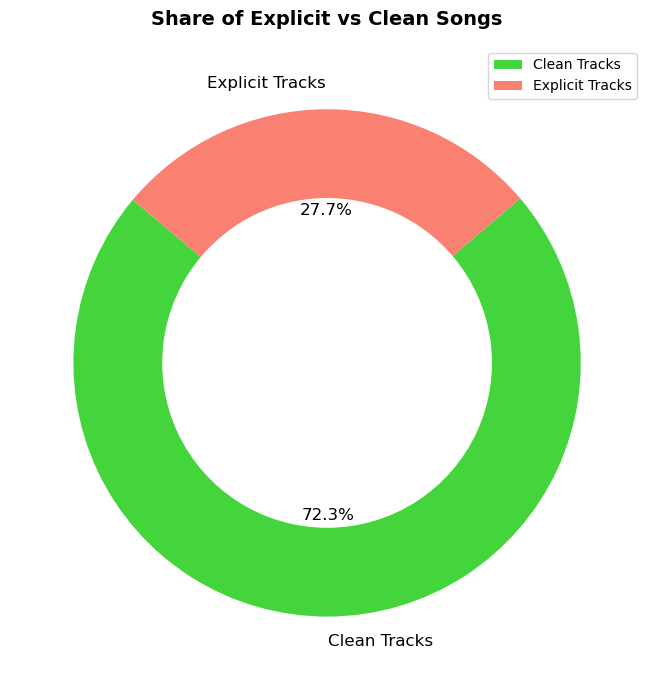

In [28]:
#  Summarize dataset by explicit flag
exp_summary = song_df.groupby('explicit')['song'].count().reset_index()

#  colors (blue for clean, red for explicit)
color_theme = ['#44D43B', '#FA8072']

#  doughnut chart
plt.figure(figsize=(7,7))
wedges, labels, pct_texts = plt.pie(
    exp_summary['song'],
    labels=['Clean Tracks', 'Explicit Tracks'],
    colors=color_theme,
    autopct="%.1f%%",
    startangle=140,
    wedgeprops=dict(width=0.35),
    textprops={'fontsize':12}
)

# Title & legend
plt.title("Share of Explicit vs Clean Songs", fontsize=14, fontweight='bold', pad=15)
plt.legend(wedges, ['Clean Tracks','Explicit Tracks'], loc="upper right", fontsize=10)

plt.tight_layout()
plt.show()


**Interpretation**

For the kind of songs explicit content is there in nearly 27.7% percent of the songs, 72..3% percent are clean.

**Business perspective**

1.The song has to be labeled as explicit by streaming services so that it can be filtered down when parental control settings are enabled.

2.Labels might consider having clean edits of explicit tracks for radio play and branding tie-ups.

3.Explicit content tells that from 2000 to 2019, a considerable number of mainstream hits were dominated by hip-hop and rap.

**Q2:Does the spotify song data reflects song with explicit content tend to be more popular than compare to clean content song?**

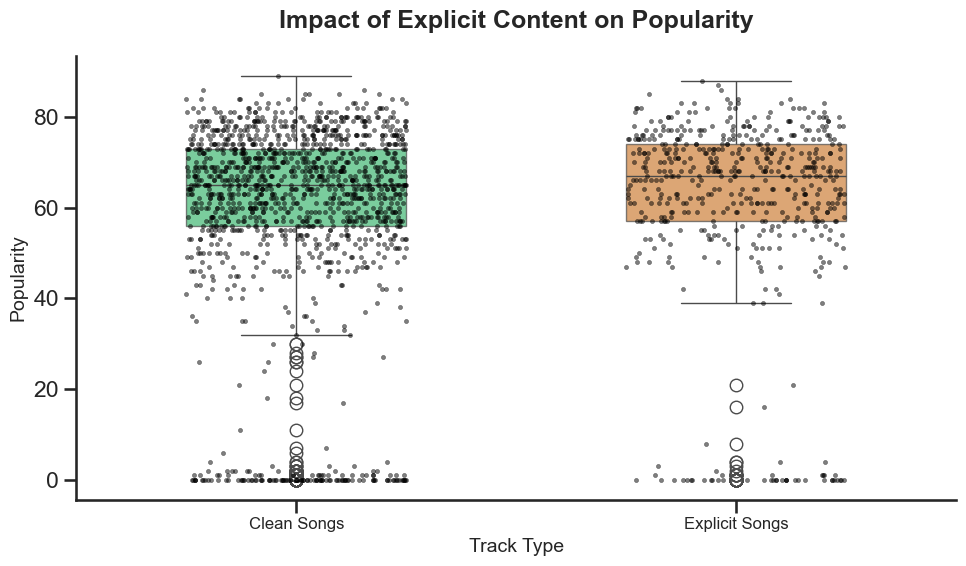

In [29]:
# Step 1: Set style
sns.set_style("ticks")
sns.set_context("talk")

# color palette (green for clean, orange for explicit)
alt_palette = ['#2ECC71', '#E67E22']  

# boxplot with hue
plt.figure(figsize=(10,6))
bx = sns.boxplot(
    x='explicit', y='popularity', hue='explicit', data=song_df, 
    palette=alt_palette, width=0.5, legend=False, boxprops=dict(alpha=0.7)
)

# Add jittered stripplot for individual points
sns.stripplot(
    x='explicit', y='popularity', data=song_df, 
    color='black', size=3, jitter=0.25, linewidth=0.4, alpha=0.5
)

# Step 4: Titles and labels
bx.set_title("Impact of Explicit Content on Popularity", fontsize=18, fontweight='bold', pad=20)
bx.set_xlabel("Track Type", fontsize=14)
bx.set_ylabel("Popularity", fontsize=14)
bx.set_xticks([0,1])
bx.set_xticklabels(["Clean Songs", "Explicit Songs"], fontsize=12)

# Step 5: for better apearance
sns.despine()
plt.tight_layout()
plt.show()



**Interpretation** 

It can be seen from the data that explicit songs tend to have a slightly higher median popularity than clean tracks, although the distribution overlaps to a great degree. This suggests that having explicit content does not create a guaranteed hit; neither does it stand in the way of mainstream success.

**Business Perspective**:

1.Streaming apps should make explicit selections discoverable while still allowing for parental-control filters.

2.The record labels may stage clean-state, as well as explicit releases: explicit tracks go for adult audiences, whereas clean edits get airplay and brand partnerships.

3.This logic goes with cultural shifts: as explicit music has gone more and more mainstream in the 2010s, it has really caught on at the charts.

# 5 Popularity Metrics

**Q1 Which artists deliver successful tracks in the year 2000 to 2019 ?**

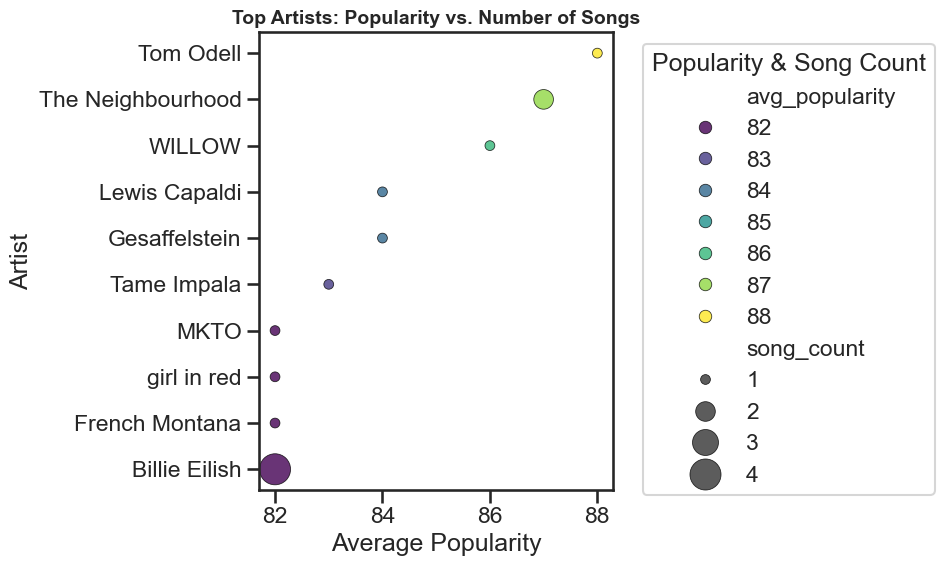

In [30]:
artist_stats = (
    song_df.groupby('artist')
    .agg(avg_popularity=('popularity','mean'),
         song_count=('song','count'))
    .sort_values(by='avg_popularity', ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))
sns.scatterplot(
    data=artist_stats,
    x='avg_popularity', 
    y=artist_stats.index,
    size='song_count',
    hue='avg_popularity',      # add hue mapping
    palette='viridis',         # color gradient
    sizes=(50, 500),
    alpha=0.8,
    edgecolor='k',
    legend='brief'
)

plt.title("Top Artists: Popularity vs. Number of Songs", fontsize=14, fontweight='bold')
plt.xlabel("Average Popularity")
plt.ylabel("Artist")
plt.legend(title="Popularity & Song Count", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


**Interpretation Top Artists by Popularity**


The analysis shows that artists such as Tom Odell (average popularity of 88, one track only), The Neighbourhood (87, 2 tracks), and WILLOW (86, 1 track) are considered the most popular artists, strictly from the means perspective, but with comparatively fewer songs in the data set. This led artists to choose the path of quality over quantity, where a single track can enchant a whole lot of audience.

In stark contrast stands Billie Eilish, another exception being four tracks at an average of 82, thus suggesting popularity and consistency across multiple songs predominate. So, a presence on the charts stems from an active combination of popularity and track volume for her. 

**Business perspective**

Streaming Platforms → Should be pushing these couple high-ranking artists with little presence in emerging/spotlight playlists for they got listener appeal coupled with growth potential.

Record labels → would view artists like Tom Odell or Lewis Capaldi as having huge hit potential, even with very few releases, and would want to invest more from a promotion standpoint. 

Whereas Billie Eilish in terms of volume and popularity is an anchor artist — her repeated success makes

# Final Discussion and Conclusion

**Strengths of the Analysis**

1.Covers a 20-year period (2000–2019) to allow the study of long-term musical trends.

2.As it includes a wide array of audio features (danceability, energy, valence, tempo, loudness, duration, popularity), one can get a complete picture on what that makes the song successful.

3.Visualizations are varied and include line charts, scatter plots, heatmaps, bubble charts, and pie charts to present insights in a clear and appealing way.

4.It balances musicistic parameters (features, genres, explicitness) with practical matters (artist performance, playlisting, marketing strategy).

**Limitations of the Analysis**

1.The dataset contains mostly Hits track, which liberates less popular tunes from the path on which this sort of statistical analysis is conducted, effectively excluding niche markets.

2.The popularity score varies with the platform (Spotify) and may otherwise fail to take into account regional or global taste variations.

The genre labels are very broad and thus do not allow for higher precision in subgenre comparison (i.e., EDM vs. House).

Correlation findings show association, not causality. Other factors out there may perhaps have some other influence: promotion, timing, cultural events.

**Key Insights and Implications for Business**

1.**Trends Over Years**:2012 marked the High point of song production, positioned as a cultural hub around which nostalgia campaigns operate. The duration of songs and its danceability went down throughout these years, keeping with the tastes of the streaming theater.

2.**Genre Differences**: Genres differ from their features: upbeat and danceable ones prevail, whereas acoustic and the other low-energy genres remain niche. Using these groundwork assumptions, platforms could derive mood-and genre-based playlists.

3.**Feature Correlations**:Strong internal correlations exist (energy with loudness: +0.65, danceability with valence: +0.40). Popularity is seldomly correlated with audio features; hence marketing and cultural relevance define chart successes. 

4.**Explicit Content**: Explicit tracks are important in terms of charted hits and during the 2010s witnessed lots of growth. They did almost as well as clean ones if not better, signposting a gradual shift in cultural norms. Businesses will have to keep parental controls on screen, however, with audience demand in sight.

5.**Top Artists**: Advanced few tracks at the high talent bands of the hits: Tom Odell (88), The Neighbourhood (87), and WILLOW (86), yet the other 'breakout' artist, Billie Eilish performed rather consistently (observable across 4 songs with 82).



# conclusion

This analysis of Spotify Top Hits (2000-2019) thus does not just take into account the trends of the day; it sets down a few concrete recommendations concerning how the industry would be functioning in the future. It is evident that trends may have shaped the graph of the current times by examining the alterations per annum in the characteristics of the songs compared to the genres, correlations compared to the explicit content, and the performance of artists.

Having these insights, it would be possible to guess which types of songs would be successful in the future: shorter, energetic, and danceable, emotionally charged. The current trends in historical hits have been used in the curation of playlists, the promotion of artists and the production so that all the three are being exposed to the evolving tastes of the listeners.

What audiences gain:

1.Streaming services receive an outline on how to do the interesting playlists by mood and nostalgia.

2.The record labels have the chance to determine which artist features and/or attributes would lead to future hits.

3.These are the tips that artists are offered in order to position their music on the market-aggressively and creatively.

4.Both feature-based and nostalgia-based campaigns can be taken by marketers to a new level of communicating with the audience.

**Reference**
Here is the link of the dataset
https://www.kaggle.com/datasets/paradisejoy/top-hits-spotify-from-20002019/data